
---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

# the Business Purpose
Objective: To predict whether a customer will complete a flight booking based on their behavior, itinerary details, and history.

# Why this matters to the airline:
Targeting the Right Customers: As we found in your model, bookings are rare. The airline wants to know who is a serious buyer vs. who is just window-shopping.

Optimizing Marketing: By identifying people with high "lead times" or long flight durations who are likely to drop their plans, the airline can automatically target them with discounts, baggage offers, or reminders to convince them to book.

Inventory Management: Knowing if a trip is likely to fail helps airlines predict demand for specific routes and seasons.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files
data =files.upload()

Saving customer_booking.csv to customer_booking (1).csv


`loading dataset `

In [ ]:
df=pd.read_csv('customer_booking.csv',encoding='ISO-8859-1')

`error in dataset `
- duplicated values
- datatype error
- outlier
- high cardinality columns -> converted to low cardinality
- one hot encoding for 2 columns
- standrization
- feature extraction mean ->instead of using route for our model as it is high cardinal we create a new column nameroute type that tell short haul medium and long haul

using sample to visualize different datapoint without biasness

In [ ]:
df.sample(8)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
23691,1,Internet,RoundTrip,64,27,15,Sat,PERSZX,Australia,0,0,0,5.62,0
14711,1,Internet,RoundTrip,58,21,13,Sun,ICNSYD,South Korea,0,0,1,8.58,0
40886,1,Internet,RoundTrip,21,5,10,Wed,MELTGG,Malaysia,1,0,1,8.83,1
565,2,Internet,RoundTrip,291,17,3,Sat,AKLKUL,Malaysia,0,0,0,8.83,0
7386,1,Internet,RoundTrip,32,17,2,Sat,CTSDPS,Japan,1,1,1,8.67,0
795,1,Internet,RoundTrip,168,28,6,Sat,AKLKUL,New Zealand,0,0,0,8.83,0
16561,1,Internet,RoundTrip,37,276,7,Thu,KIXMEL,Japan,1,1,1,8.83,0
5601,1,Internet,RoundTrip,267,19,3,Sun,CMBSYD,Australia,0,0,1,8.58,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
     - int no need to change
- `sales_channel` = sales channel booking was through
     - object no need to change datatype
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)these describe whether person gose directly from a to b and back to a or only go to b from a or it go to b from a with different stop respectively
     - object no need to change
- `purchase_lead` = number of days between travel date and booking date
     - - int not need to chnage because if we use timedelta datatype random forest get confuse for string "days"
- `length_of_stay` = number of days spent at destination
     - int not need to chnage because if we use timedelta datatype random forest get confuse for string "days"
- `flight_hour` = hour of flight departure
     - int change to time
- `flight_day` = day of week of flight departure
     - object should convert to week days using category
- `route` = origin -> destination flight route
     - object no need to change
- `booking_origin` = country from where booking was made
     - object no need to change
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
     - int no need tto change
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
     - int no need to change
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
    - int no need to change
- `flight_duration` = total duration of flight (in hours)
    - float converted to hours The Best Data Type: float64 (decimal number).Why: Because it is a physical measurement, keeping it as a decimal allows the model to understand that a $9.5$-hour flight is twice as long as a $4.75$-hour flight.
- `booking_complete` = flag indicating if the customer completed the booking
    - int no need to change
Before we compute any statistics on the data, lets do any necessary data conversion

In [ ]:
#converting flight day to category
day_map = {"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7}
df['flight_day'] = df['flight_day'].map(day_map).astype('category')

In [ ]:
#converting flight hour to time datatype
df['flight_hour'] = df['flight_hour'].astype('category')

In [ ]:
#testing
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   num_passengers         50000 non-null  int64   
 1   sales_channel          50000 non-null  object  
 2   trip_type              50000 non-null  object  
 3   purchase_lead          50000 non-null  int64   
 4   length_of_stay         50000 non-null  int64   
 5   flight_hour            50000 non-null  category
 6   flight_day             50000 non-null  category
 7   route                  50000 non-null  object  
 8   booking_origin         50000 non-null  object  
 9   wants_extra_baggage    50000 non-null  int64   
 10  wants_preferred_seat   50000 non-null  int64   
 11  wants_in_flight_meals  50000 non-null  int64   
 12  flight_duration        50000 non-null  float64 
 13  booking_complete       50000 non-null  int64   
dtypes: category(2), float64(1), int64(7), 

The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [ ]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,1.000000,1.000000,1.000000,9.500000,1.000000


using `duplicated ` to check duplicated values
- there are 719 duplicated values

conclusion

- dropping duplicated  values

In [ ]:
df.duplicated().sum()

np.int64(719)

In [ ]:
#checking duplicated value
df[df.duplicated()]

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
196,5,Internet,RoundTrip,206,17,13,7,AKLKUL,Malaysia,1,0,0,8.83,0
316,5,Internet,RoundTrip,206,17,13,7,AKLKUL,Malaysia,1,0,0,8.83,0
384,5,Internet,RoundTrip,206,17,13,7,AKLKUL,Malaysia,1,0,0,8.83,0
456,1,Internet,RoundTrip,30,85,15,5,AKLKUL,Malaysia,1,0,0,8.83,1
513,3,Internet,RoundTrip,109,20,4,2,AKLKUL,Singapore,1,0,1,8.83,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49852,2,Internet,RoundTrip,204,6,14,2,PENTPE,Malaysia,1,0,0,4.67,0
49902,1,Mobile,RoundTrip,106,6,11,5,PENTPE,Taiwan,1,0,0,4.67,0
49934,1,Internet,RoundTrip,2,6,3,4,PENTPE,Malaysia,0,0,1,4.67,0
49944,1,Internet,RoundTrip,2,6,3,4,PENTPE,Malaysia,0,0,1,4.67,0


In [ ]:
# droping duplicated value
df=df.drop_duplicates()

In [ ]:
# checking
df.shape

(49281, 14)

checking `null values ` in dataset
- no null values

In [ ]:
df.isnull().sum()


,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


`checking` outlier in `categorical column `

In [ ]:
print(df['flight_day'].value_counts())

flight_day
1    7988
3    7562
2    7558
4    7323
5    6685
7    6442
6    5723
Name: count, dtype: int64


no outlier

outlier checking in `flight hour` categorical column

In [ ]:
print(df['flight_hour'].value_counts())

flight_hour
8     3125
12    3114
9     3097
7     3080
11    3071
10    3050
13    3046
6     3010
5     2817
4     2786
14    2783
3     2616
2     2596
15    2201
1     2071
16    1536
0     1501
23     975
17     848
22     573
18     430
21     386
19     294
20     275
Name: count, dtype: int64


result : no outlier in this column

checking `outlier ` in numerical column


In [ ]:
def check_outliers(dataframe, column_name):
    # 1. Calculate the 25th and 75th percentiles (Q1 and Q3)
    q1 = dataframe[column_name].quantile(0.25)
    q3 = dataframe[column_name].quantile(0.75)

    # 2. Compute the Interquartile Range (IQR)
    iqr = q3 - q1

    # 3. Define the fences (boundaries)
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    # 4. Count how many data points fall outside the fences
    min_outliers = dataframe[dataframe[column_name] < lower_fence].shape[0]
    max_outliers = dataframe[dataframe[column_name] > upper_fence].shape[0]

    # 5. Display the diagnostic report
    print(f"📊 --- Outlier Report for '{column_name}' ---")
    print(f"Lower Fence (Min Limit): {lower_fence:.2f} | Found: {min_outliers} minimum outliers")
    print(f"Upper Fence (Max Limit): {upper_fence:.2f} | Found: {max_outliers} maximum outliers")
    print(f"Total Outliers in Column: {min_outliers + max_outliers}\n")
    # Check salary
check_outliers(df, 'purchase_lead')
check_outliers(df, 'length_of_stay')
check_outliers(df, 'flight_duration')


📊 --- Outlier Report for 'purchase_lead' ---
Lower Fence (Min Limit): -120.00 | Found: 0 minimum outliers
Upper Fence (Max Limit): 256.00 | Found: 3391 maximum outliers
Total Outliers in Column: 3391

📊 --- Outlier Report for 'length_of_stay' ---
Lower Fence (Min Limit): -29.50 | Found: 0 minimum outliers
Upper Fence (Max Limit): 62.50 | Found: 3748 maximum outliers
Total Outliers in Column: 3748

📊 --- Outlier Report for 'flight_duration' ---
Lower Fence (Min Limit): 0.81 | Found: 0 minimum outliers
Upper Fence (Max Limit): 13.64 | Found: 0 maximum outliers
Total Outliers in Column: 0



`capping` outlier to avoid error

In [ ]:
for col in ['purchase_lead','length_of_stay']:
  lower_limit=df[col].quantile(0.01)
  upper_limit=df[col].quantile(0.99)
  df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)


In [ ]:
#checking method 1
df[['purchase_lead','length_of_stay']].describe()

,purchase_lead,length_of_stay
count,49281.000000,49281.000000
mean,84.436172,22.248392
std,89.258826,27.697420
min,1.000000,2.000000
25%,21.000000,5.000000
50%,51.000000,17.000000
75%,115.000000,28.000000
max,390.000000,167.000000


In [ ]:
#checking method 2
for col in ['purchase_lead', 'length_of_stay']:
    print(f"--- {col} Check ---")
    print(f"Clipped Min: {df[col].min()}  | (Expected 1st percentile)")
    print(f"Clipped Max: {df[col].max()} | (Expected 99th percentile)")
    print()

--- purchase_lead Check ---
Clipped Min: 1  | (Expected 1st percentile)
Clipped Max: 390 | (Expected 99th percentile)

--- length_of_stay Check ---
Clipped Min: 2  | (Expected 1st percentile)
Clipped Max: 167 | (Expected 99th percentile)



In [ ]:
# checking method 3
for col in ['purchase_lead', 'length_of_stay']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    # Calculate the count
    beyondofrange = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    # UNCOMMENTED AND FIXED: Matching the variable name exactly!
    print(f"Number of out-of-bounds values in {col}: {beyondofrange}")

Number of out-of-bounds values in purchase_lead: 0
Number of out-of-bounds values in length_of_stay: 0


In [ ]:
# final check
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

# `EDA`

`numerical column `
- purchase_lead
- length_of_stay
- want extra baggage
- extra seat
- booking complete
- want meal
- flight duration

======================

`categorical column `
- sales channel
- trip type
- route
- booking origin
- flight hour
- flight day

# univariate analysis

Text(0.5, 0, 'purchase lead')

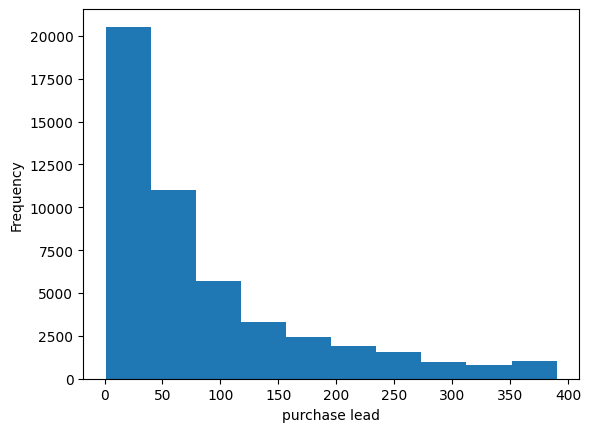

In [ ]:
#purchase lead
df['purchase_lead'].plot(kind='hist')
plt.xlabel('purchase lead')

Text(0.5, 0, 'purchase lead')

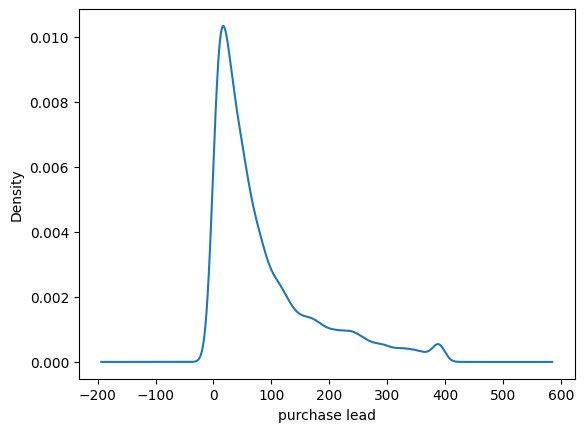

In [ ]:
df['purchase_lead'].plot(kind='kde')
plt.xlabel('purchase lead')

In [ ]:
df['purchase_lead'].skew()

np.float64(1.5748982542640682)

Text(0.5, 0, 'purchase lead')

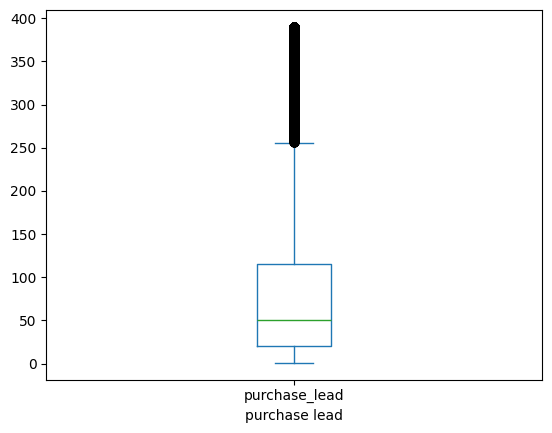

In [ ]:
df['purchase_lead'].plot(kind='box')
plt.xlabel('purchase lead')

`conclusion:`

Most people book their flights last-minute or within a month or two of departure (the big spike on the left). Only a small, select group of planners book their trips almost a year in advance (the long tail on the right).

Text(0.5, 0, 'length_of_stay')

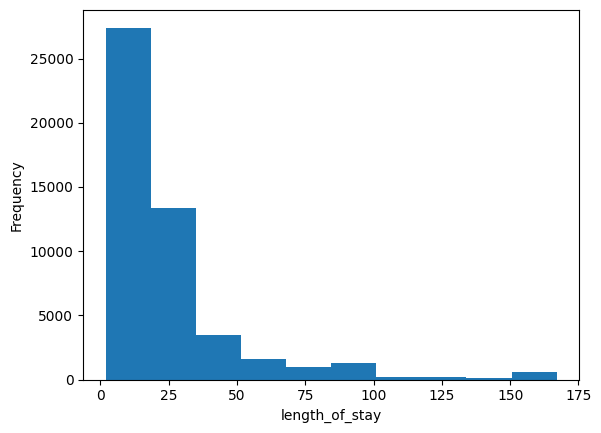

In [ ]:
#length_of _stay
df['length_of_stay'].plot(kind='hist')
plt.xlabel('length_of_stay')

Text(0.5, 0, 'length_of_stay')

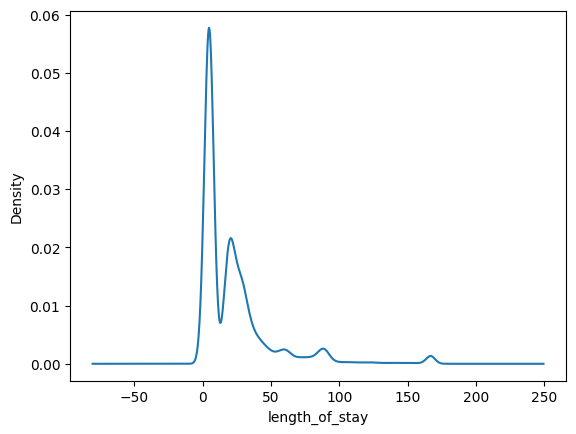

In [ ]:
#length_of _stay
df['length_of_stay'].plot(kind='kde')
plt.xlabel('length_of_stay')

In [ ]:
df['length_of_stay'].skew()

np.float64(2.724100295518693)

Text(0.5, 0, 'length_of_stay')

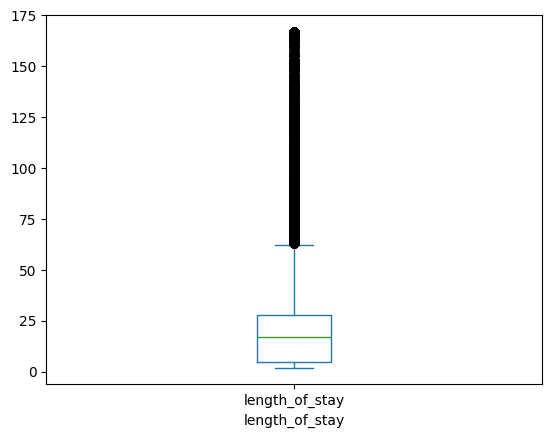

In [ ]:
#length_of _stay
df['length_of_stay'].plot(kind='box')
plt.xlabel('length_of_stay')

`conclusion:`

The Massive First Peak (0 to 10 days): This is where the vast majority of bookings live. These are short-term travelers—likely taking quick weekend getaways, short business trips, or 1-week vacations.

The Second Peak (around 20 days): This represents your classic 2-to-3-week holidaymakers (very common for international flights).

The Tiny Humps further out (near 90 and 170 days): These represent extreme long-term stays—likely exchange students, expats visiting family back home, or long-term remote workers.

it rightly skewed

Text(0.5, 0, 'flight_duration')

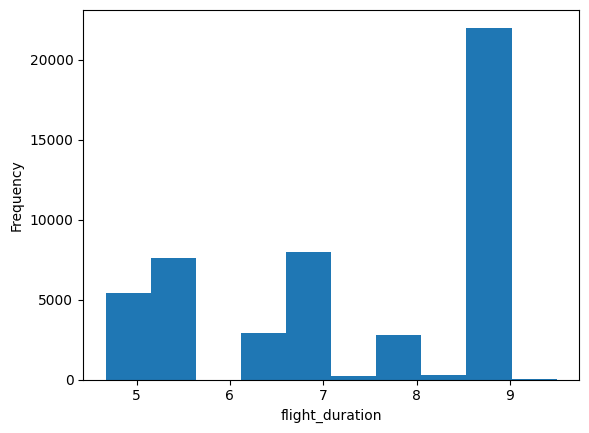

In [ ]:
##flight_duration
df['flight_duration'].plot(kind='hist')
plt.xlabel('flight_duration')

Text(0.5, 0, 'flight_duration')

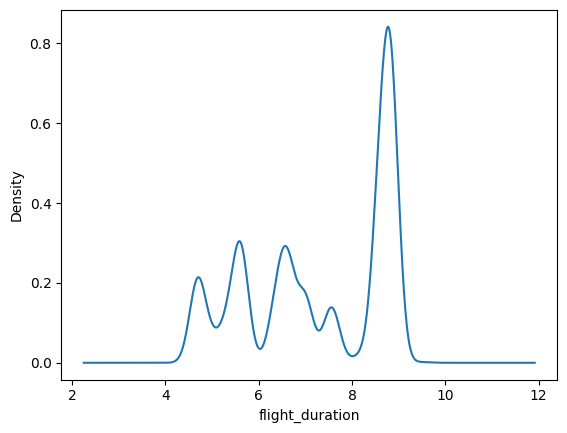

In [ ]:
##flight_duration
df['flight_duration'].plot(kind='kde')
plt.xlabel('flight_duration')

In [ ]:
df['flight_duration'].skew()

np.float64(-0.36211025528898444)

`conclusion :`
major flight time it 9 hour for long distance countries and minimum distance is 4.5 hours

Text(0.5, 0, 'fwants_extra_baggage')

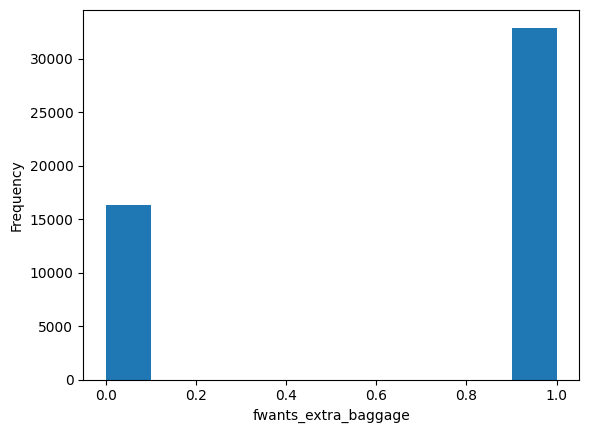

In [ ]:
##want extra meal
df['wants_extra_baggage'].plot(kind='hist')
plt.xlabel('fwants_extra_baggage')

conclusion:

more then 30000 coustomer want extra luggage



Text(0.5, 0, 'wants_preferred_seat')

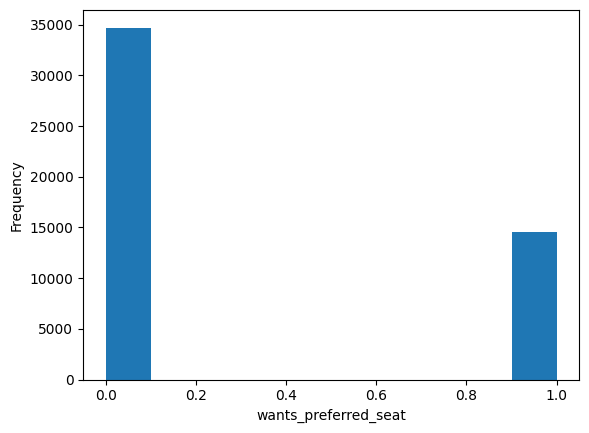

In [ ]:
##want extra meal
df['wants_preferred_seat'].plot(kind='hist')
plt.xlabel('wants_preferred_seat')

conclusion:
most coustomer donot want preffered seat

Text(0.5, 0, 'wants_preferred_seat')

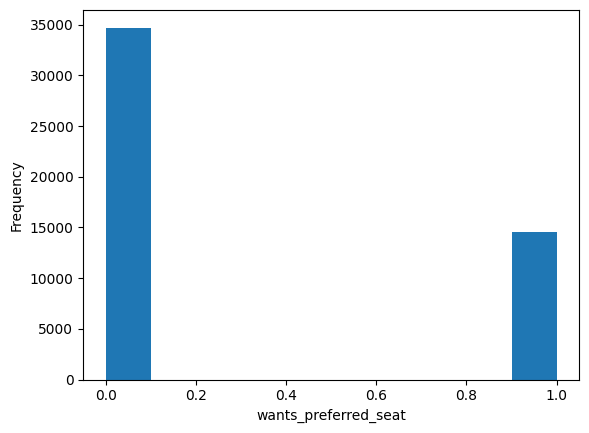

In [ ]:
##want extra meal
df['wants_preferred_seat'].plot(kind='hist')
plt.xlabel('wants_preferred_seat')

conclusion:
most coustomer do not prefer meal

# `univariate on categorical `

<Axes: ylabel='count'>

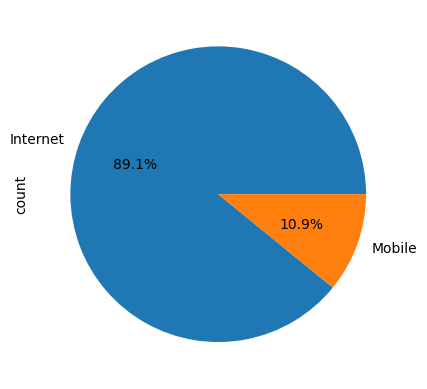

In [ ]:
df['sales_channel'].value_counts().plot(kind='pie',autopct='%0.1f%%')

`conclusion:`
most people book flight through internet


<Axes: xlabel='trip_type'>

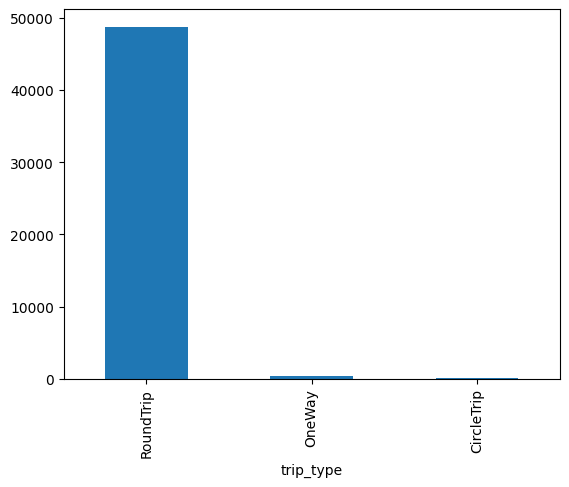

In [ ]:
df['trip_type'].value_counts().plot(kind='bar')

`conclusion:`

most people book round trip >one way >circle trip

<Axes: ylabel='flight_day'>

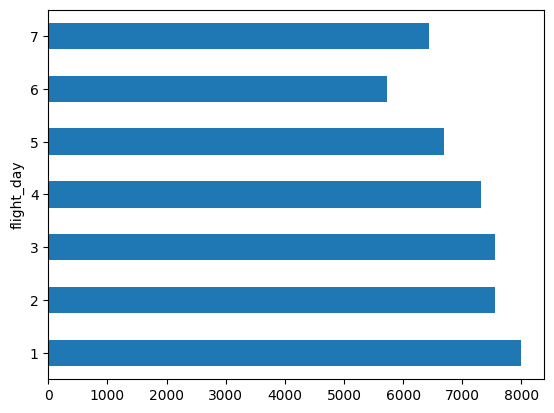

In [ ]:
df['flight_day'].astype(str).value_counts().sort_index().plot(kind='barh')

most busiest day for booking flight is monday and least is saturday

<Axes: ylabel='flight_hour'>

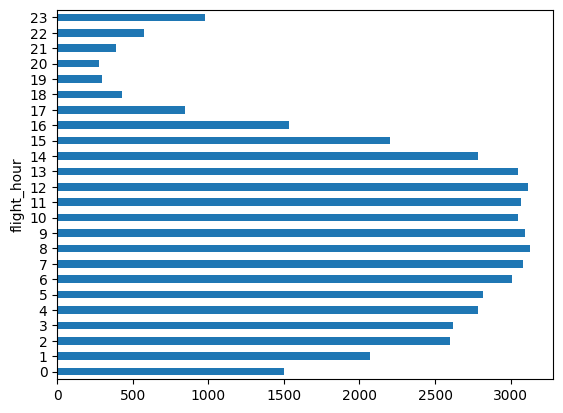

In [ ]:
df['flight_hour'].value_counts().sort_index().plot(kind='barh')

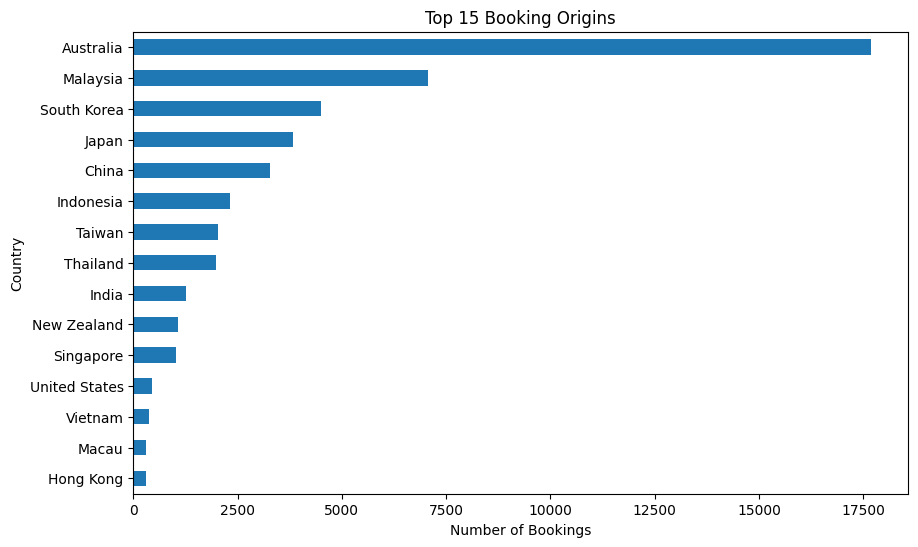

In [ ]:
df['booking_origin'].value_counts().plot(kind='pie',autopct='%0.1f%%')

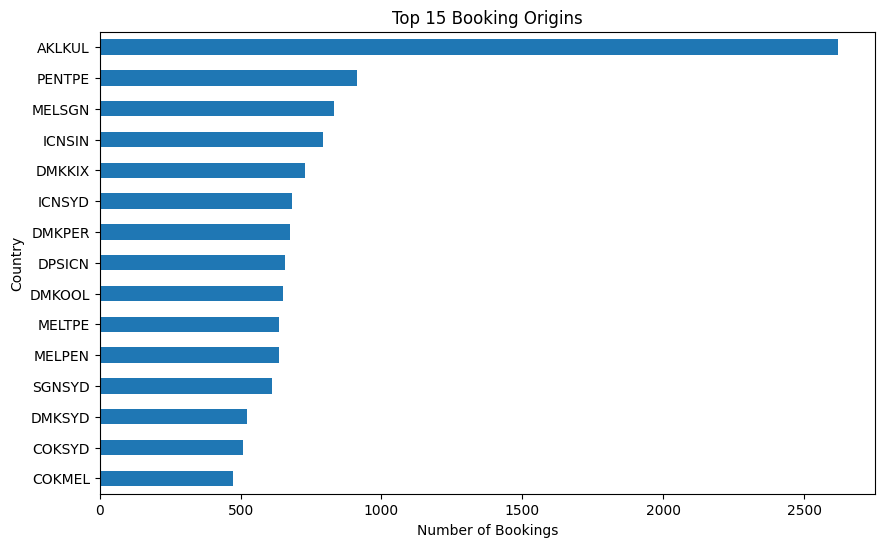

In [ ]:
plt.figure(figsize=(10, 6))
df['route'].value_counts().nlargest(15).plot(kind='barh').invert_yaxis()

plt.title('Top 15 Booking Origins')
plt.xlabel('Number of Bookings')
plt.ylabel('Country')
plt.show()

# `bivariate analysis `

/tmp/ipykernel_3152/545259528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='booking_complete', y='purchase_lead', palette='Set2')


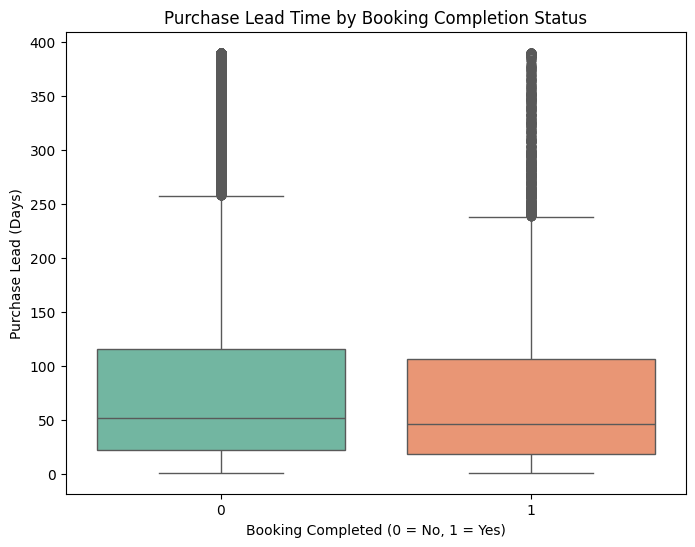

In [ ]:
plt.figure(figsize=(8, 6))
# Using seaborn to plot purchase_lead split by booking_complete
sns.boxplot(data=df, x='booking_complete', y='purchase_lead', palette='Set2')

plt.title('Purchase Lead Time by Booking Completion Status')
plt.xlabel('Booking Completed (0 = No, 1 = Yes)')
plt.ylabel('Purchase Lead (Days)')
plt.show()

`conclusion`

- This means the overall booking behavior of both groups is incredibly similar. Whether someone books 3 weeks or 3 months in advance doesn't heavily guarantee whether they will complete the booking.

- Those extremely long lead times (over a year in advance) are rare anomalies in both completed and uncompleted bookings.

/tmp/ipykernel_3152/3605884015.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='length_of_stay', x='booking_complete', palette='Set2')


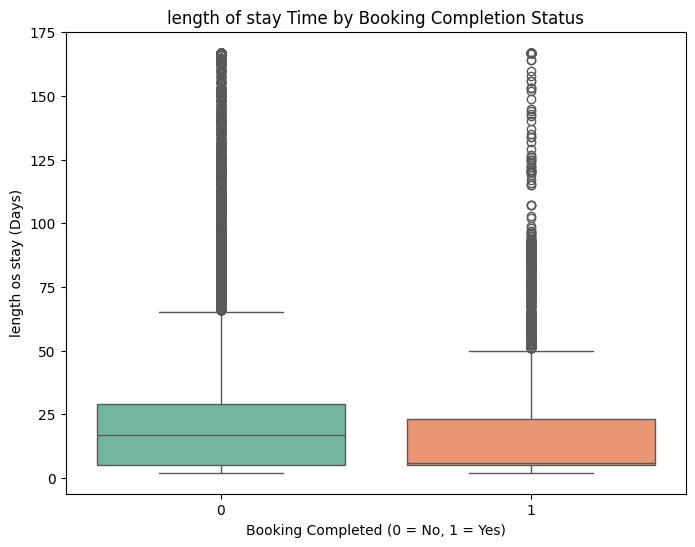

In [ ]:
plt.figure(figsize=(8, 6))
# Using seaborn to plot purchase_lead split by booking_complete
sns.boxplot(data=df, y='length_of_stay', x='booking_complete', palette='Set2')

plt.title('length of stay Time by Booking Completion Status')
plt.xlabel('Booking Completed (0 = No, 1 = Yes)')
plt.ylabel('length os stay (Days)')
plt.show()

"There is a clear behavioral difference in trip length. Successful buyers overwhelmingly favor shorter trips, with $75\%$ of completed bookings lasting $24$ days or less, and normal staying patterns capping out at $50$ days. On the other hand, non-buyers tend to plan longer, more speculative stays that stretch up to $65$ days before becoming statistical outliers."

/tmp/ipykernel_3152/3225586670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='booking_complete', ax=axes[i], palette='Set2', errorbar=None)
/tmp/ipykernel_3152/3225586670.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(['{:,.1%}'.format(x) for x in vals])
/tmp/ipykernel_3152/3225586670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='booking_complete', ax=axes[i], palette='Set2', errorbar=None)
/tmp/ipykernel_3152/3225586670.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

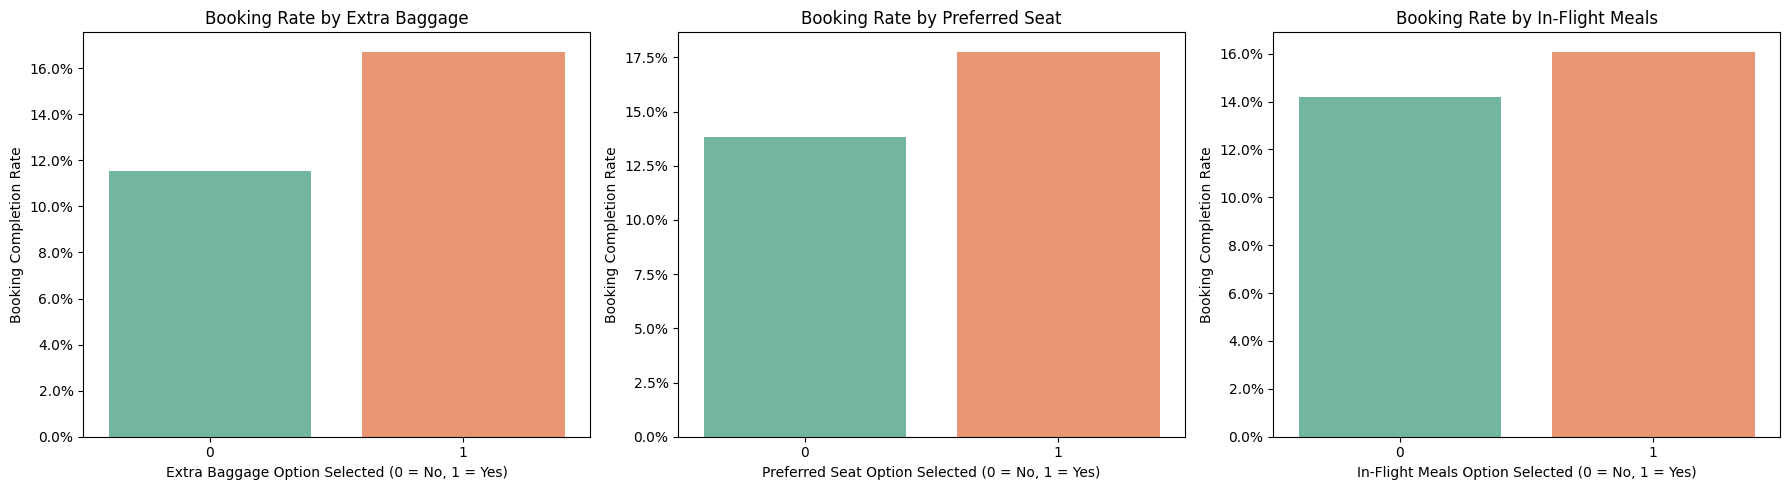

In [ ]:
# Set up a clean 1x3 grid of plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']
titles = ['Extra Baggage', 'Preferred Seat', 'In-Flight Meals']

for i, col in enumerate(features):
    # Using a barplot with a binary target automatically plots the MEAN (completion rate)!
    sns.barplot(data=df, x=col, y='booking_complete', ax=axes[i], palette='Set2', errorbar=None)

    axes[i].set_title(f'Booking Rate by {titles[i]}')
    axes[i].set_ylabel('Booking Completion Rate')
    axes[i].set_xlabel(f'{titles[i]} Option Selected (0 = No, 1 = Yes)')

    # Format the y-axis to show percentages beautifully
    vals = axes[i].get_yticks()
    axes[i].set_yticklabels(['{:,.1%}'.format(x) for x in vals])

plt.tight_layout()
plt.show()

so from this i analyse that coustomer whoo booked there ticket opt for extra baggage meal and prefer seat then non coustomer

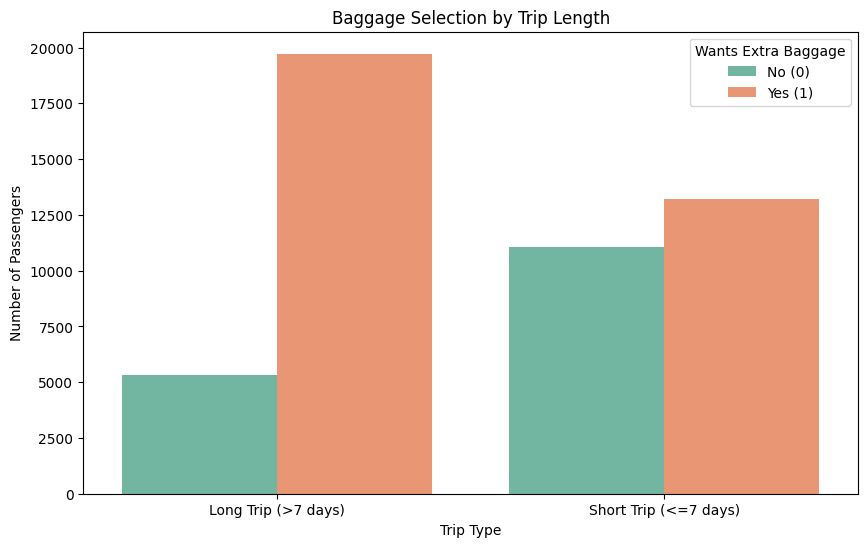

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Let's create a temporary column to define "Short Trip" (e.g., <= 7 days) vs "Long Trip"
df['trip_type_len'] = df['length_of_stay'].apply(lambda x: 'Short Trip (<=7 days)' if x <= 7 else 'Long Trip (>7 days)')

# Let's plot how many short-trippers vs long-trippers opt for extra baggage
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='trip_type_len', hue='wants_extra_baggage', palette='Set2')

plt.title('Baggage Selection by Trip Length')
plt.xlabel('Trip Type')
plt.ylabel('Number of Passengers')
plt.legend(title='Wants Extra Baggage', labels=['No (0)', 'Yes (1)'])
plt.show()

`conclusion :` whether customer book ticket for long trip or short they will go for extra luggage opt

/tmp/ipykernel_1239/3974293721.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sales_channel', y='booking_complete', ax=axes[0], palette='Set2', errorbar=None)
/tmp/ipykernel_1239/3974293721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='trip_type', y='booking_complete', ax=axes[1], palette='Set2', errorbar=None)
/tmp/ipykernel_1239/3974293721.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='flight_day', y='booking_complete', ax=axes[2], palette='Set2', errorbar=None,
/tmp/ipykernel_1239/3974

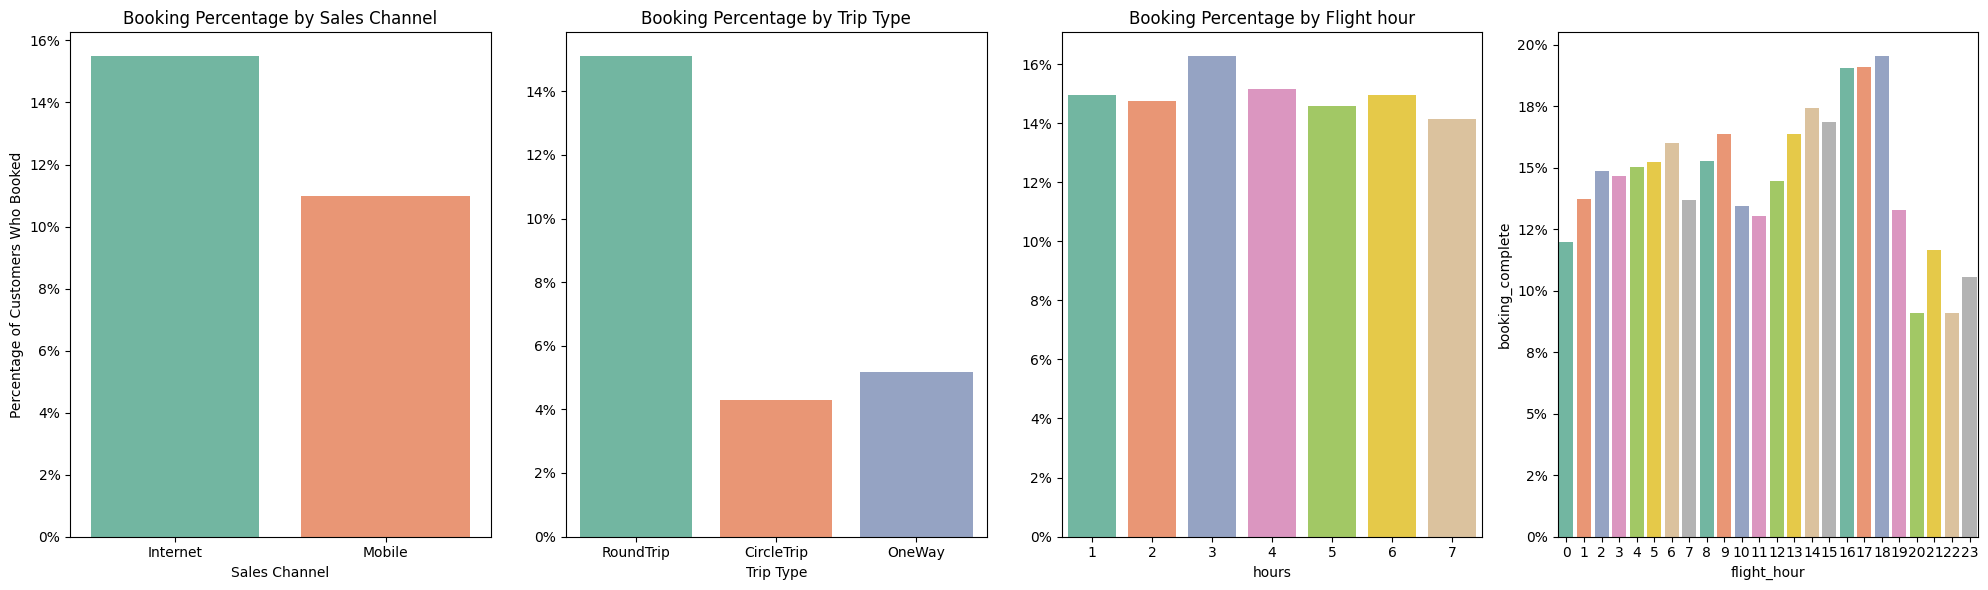

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up a 1x3 grid for our remaining categorical variables
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# 1. Bivariate: Sales Channel vs Booking Completion %
sns.barplot(data=df, x='sales_channel', y='booking_complete', ax=axes[0], palette='Set2', errorbar=None)
axes[0].set_title('Booking Percentage by Sales Channel')
axes[0].set_ylabel('Percentage of Customers Who Booked')
axes[0].set_xlabel('Sales Channel')

# 2. Bivariate: Trip Type vs Booking Completion %
sns.barplot(data=df, x='trip_type', y='booking_complete', ax=axes[1], palette='Set2', errorbar=None)
axes[1].set_title('Booking Percentage by Trip Type')
axes[1].set_ylabel('')
axes[1].set_xlabel('Trip Type')

# 3. Bivariate: Flight Day vs Booking Completion %
# Sorting days 1 to 7 so the chart reads nicely from Monday to Sunday
sns.barplot(data=df, x='flight_day', y='booking_complete', ax=axes[2], palette='Set2', errorbar=None,
            order=sorted(df['flight_day'].unique()))
axes[2].set_title('Booking Percentage by Flight Day')
axes[2].set_ylabel('')
axes[2].set_xlabel('Day of the Week (1=Mon, 7=Sun)')

# 3. Bivariate: Flight Day vs Booking Completion %
# Sorting days 1 to 7 so the chart reads nicely from Monday to Sunday
sns.barplot(data=df, x='flight_hour', y='booking_complete', ax=axes[3], palette='Set2', errorbar=None,
            order=sorted(df['flight_hour'].unique()))
axes[2].set_title('Booking Percentage by Flight hour')
axes[2].set_ylabel('')
axes[2].set_xlabel('hours')

# Format all y-axes to display as clean percentages (e.g., 15%)
for ax in axes:
    vals = ax.get_yticks()
    ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])

plt.tight_layout()
plt.show()

`conclusion:`
Internet (15.5%) clearly beats Mobile (11%), and RoundTrip (15%) completely dominates Circle Trips and One Way tickets (both under 6%).

Hour 16 (4 PM) is ~19%

Hour 17 (5 PM) is ~19%

Hour 18 (6 PM) is the highest peak at nearly 20%!

At hour 19 (7 PM), it drops back down significantly to ~13%.

The prime booking window is actually late afternoon to early evening: 4 PM, 5 PM, and 6 PM.

# `multivariate analysis`

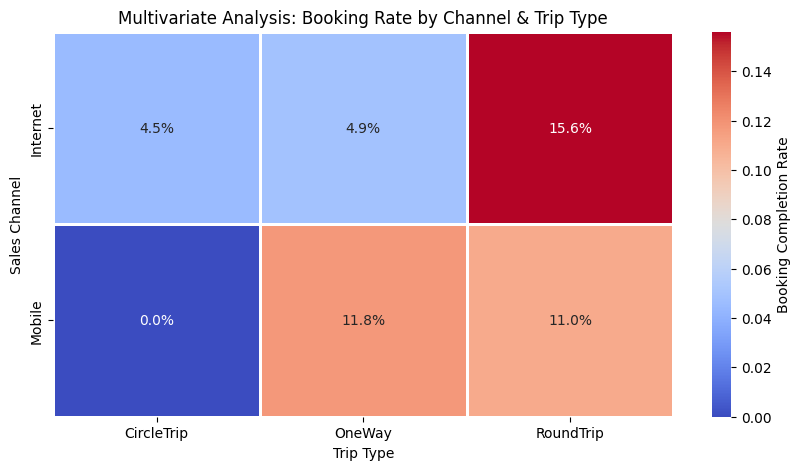

In [ ]:
# 1. Create a pivot table calculating the average booking rate for each combination
multivariate_pivot = df.pivot_table(values='booking_complete',
                                     index='sales_channel',
                                     columns='trip_type',
                                     aggfunc='mean')

# 2. Plot it as a beautifully annotated heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(multivariate_pivot, annot=True, cmap='coolwarm', fmt=".1%", linewidths=1, cbar_kws={'label': 'Booking Completion Rate'})

plt.title('Multivariate Analysis: Booking Rate by Channel & Trip Type')
plt.xlabel('Trip Type')
plt.ylabel('Sales Channel')
plt.show()

"Complex trips (Round Trips) are finished on computers, while urgent, simple trips (One-Way) perform surprisingly well on mobile devices. Multi-city trips (Circle Trips) completely fail on mobile platforms."

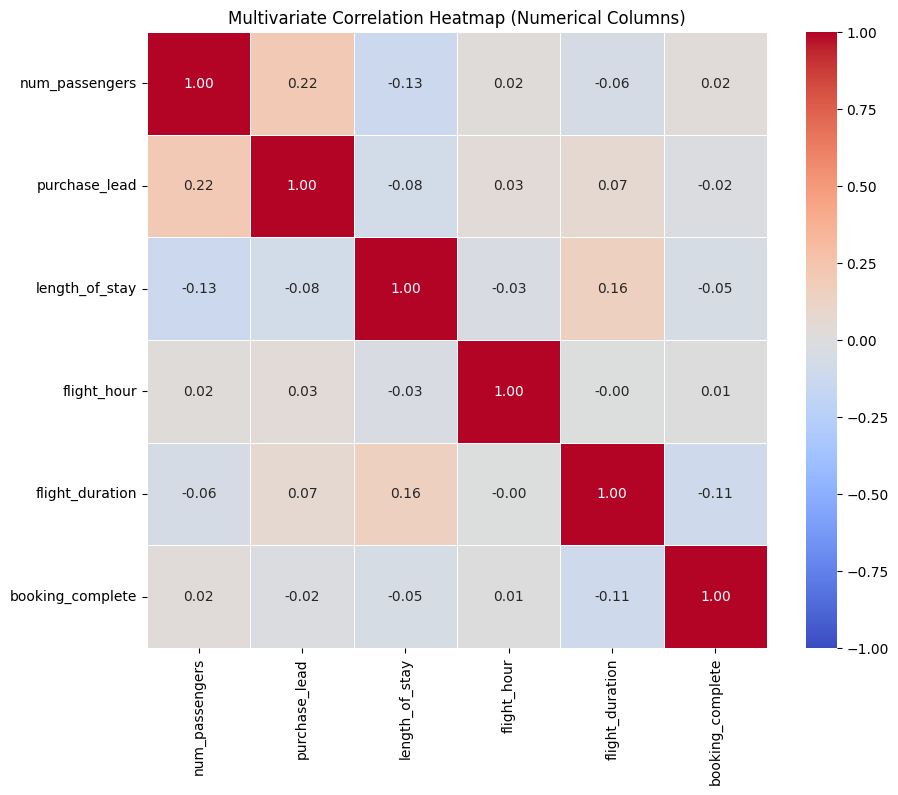

In [ ]:
plt.figure(figsize=(10, 8))

# 1. Select the key numerical columns
numerical_cols = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration', 'booking_complete']

# 2. Calculate the Pearson correlation matrix
corr_matrix = df[numerical_cols].corr()

# 3. Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Multivariate Correlation Heatmap (Numerical Columns)')
plt.show()

- If people plan very long before the trip, they are more likely to drop their plan.
- If length of stay is more, then booking may not happen.
- If flight duration is more, then maybe the booking fails.
-

In [ ]:
def get_route_type(duration):
    if duration <= 3:
        return 'Short Haul'
    elif duration <= 6:
        return 'Medium Haul'
    else:
        return 'Long Haul'

# Create the new route_type column
df['route_type'] = df['flight_duration'].apply(get_route_type)

# Drop the original high-cardinality route column
df = df.drop(columns=['route'])

# Check our new column distribution
print(df['route_type'].value_counts())

route_type
Long Haul      36217
Medium Haul    13064
Name: count, dtype: int64


In [ ]:
# Find the top 10 most frequent countries
top_10_countries = df['booking_origin'].value_counts().nlargest(10).index

# Keep top 10, group everything else into 'Other'
df['booking_origin'] = df['booking_origin'].apply(lambda x: x if x in top_10_countries else 'Other')

# Check the new clean distribution
print(df['booking_origin'].value_counts())

booking_origin
Australia      17691
Malaysia        7055
South Korea     4502
Other           4260
Japan           3819
China           3284
Indonesia       2317
Taiwan          2042
Thailand        1993
India           1258
New Zealand     1060
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select the numerical columns you want to standardize
numerical_cols = ['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_duration']

# Apply the scaler to those columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Preview your final, fully engineered dataset!
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,route_type
0,0.403150,Internet,RoundTrip,1.989334,-0.117283,-0.382535,6,New Zealand,1,0,0,-1.176158,0,Medium Haul
1,-0.580591,Internet,RoundTrip,0.308811,-0.081178,-1.121490,6,New Zealand,0,0,0,-1.176158,0,Medium Haul
2,0.403150,Internet,RoundTrip,1.776468,-0.008968,1.464855,3,India,1,1,0,-1.176158,0,Medium Haul
3,-0.580591,Internet,RoundTrip,0.129555,0.315975,-0.936751,6,New Zealand,0,0,1,-1.176158,0,Medium Haul
4,0.403150,Internet,RoundTrip,-0.184142,-0.008968,1.095377,3,India,1,0,1,-1.176158,0,Medium Haul


In [ ]:
import pandas as pd

# One-hot encode sales_channel, route_type, AND trip_type
df = pd.get_dummies(df, columns=['sales_channel', 'route_type', 'trip_type'], drop_first=True, dtype=int)

# Verify all our new dummy columns are present
df.columns

Index(['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
       'flight_day', 'booking_origin', 'wants_extra_baggage',
       'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration',
       'booking_complete', 'sales_channel_Mobile', 'route_type_Medium Haul',
       'trip_type_OneWay', 'trip_type_RoundTrip'],
      dtype='object')

# `model implementation`

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separate the target variable (y) from the predictors (X)
X = df.drop(columns=['booking_complete', 'flight_day', 'booking_origin']) # Dropping remaining unencoded text/day columns
y = df['booking_complete']

# 2. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('# Training set shape:')
print(X_train.shape, y_train.shape)
print("\nTesting set shape:")
print(X_test.shape, y_test.shape)

# Training set shape:
(39424, 12) (39424,)

Testing set shape:
(9857, 12) (9857,)


added stratify=y because, as we saw in your EDA, booking completions are quite rare. This ensures both your training and testing sets get the exact same percentage of successful bookings.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the Random Forest Classifier
# We set class_weight='balanced' because booking completions are rare (imbalanced data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)

# 2. Train the model on your training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = rf_model.predict(X_test)

# 4. Print out the performance metrics
print("=== Model Accuracy ===")
print(f"{accuracy_score(y_test, y_pred):.2%}\n")

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Model Accuracy ===
70.39%

=== Confusion Matrix ===
[[6118 2261]
 [ 658  820]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      8379
           1       0.27      0.55      0.36      1478

    accuracy                           0.70      9857
   macro avg       0.58      0.64      0.58      9857
weighted avg       0.81      0.70      0.74      9857



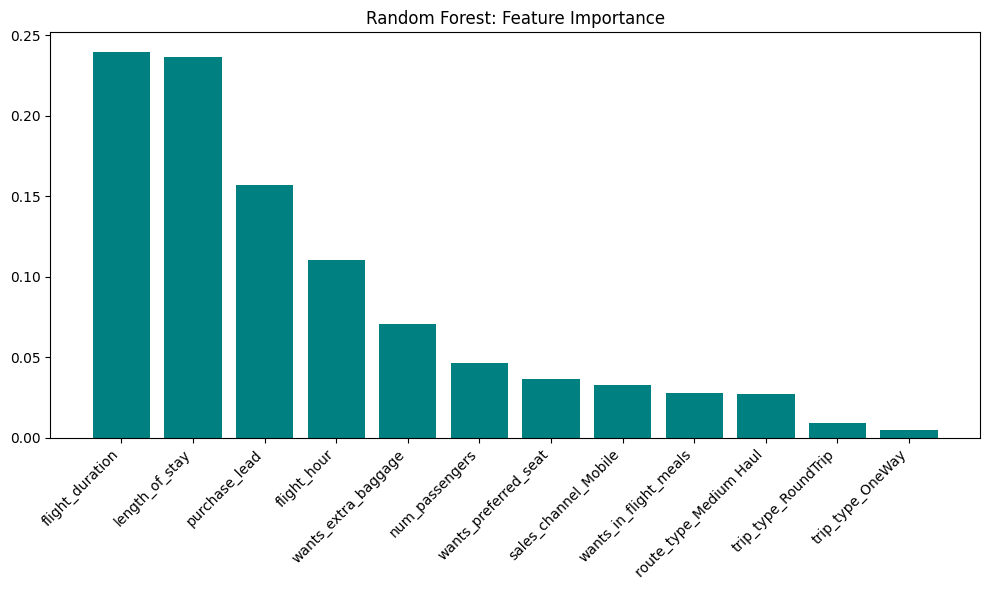

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get feature importances from the model
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Sort them in descending order
indices = np.argsort(importances)[::-1]

# 3. Plot the importances
plt.figure(figsize=(10, 6))
plt.title("Random Forest: Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center", color="teal")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Define the grid of parameters we want to test
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [8, 12],
    'min_samples_split': [5, 10]
}

# 2. Initialize a clean Random Forest base model
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# 3. Set up Grid Search with 3-fold cross-validation
# We score based on 'f1' to balance precision and recall perfectly
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)

print("Tuning hyperparameters... This might take a minute...")
grid_search.fit(X_train, y_train)

# 4. Extract the best model found by the search
best_rf_model = grid_search.best_estimator_

# 5. Test the tuned model's performance
y_pred_tuned = best_rf_model.predict(X_test)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)

print("\n=== Tuned Model Accuracy ===")
print(f"{accuracy_score(y_test, y_pred_tuned):.2%}")

print("\n=== Tuned Classification Report ===")
print(classification_report(y_test, y_pred_tuned))

Tuning hyperparameters... This might take a minute...

=== Best Parameters Found ===
{'max_depth': 8, 'min_samples_split': 10, 'n_estimators': 150}

=== Tuned Model Accuracy ===
68.25%

=== Tuned Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      8379
           1       0.26      0.59      0.36      1478

    accuracy                           0.68      9857
   macro avg       0.58      0.64      0.57      9857
weighted avg       0.81      0.68      0.72      9857



In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation using F1-score (best for imbalanced data)
cv_scores = cross_val_score(best_rf_model, X, y, cv=5, scoring='f1', n_jobs=-1)

print("=== Cross-Validation Results ===")
print(f"F1-Scores per fold: {cv_scores}")
print(f"Mean Cross-Validation F1-Score: {cv_scores.mean():.4f}")

=== Cross-Validation Results ===
F1-Scores per fold: [0.14479638 0.19872329 0.         0.01534367 0.27204728]
Mean Cross-Validation F1-Score: 0.1262
